# P3 — Modelo predictivo (scoring de riesgo)

Modelo de scoring de probabilidad de impago, comparando un baseline de
regresión logística contra LightGBM. Split estratificado por `TARGET_COL`
dado el desbalance de clases (~6.7% positivos).

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

from src.config import SEED, TARGET_COL, MODELS_DIR, MLFLOW_TRACKING_URI, POWERBI_DIR
from src.data import load_raw_training
from src.preprocessing import fit_preprocessing, apply_preprocessing

np.random.seed(SEED)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)


def ks_stat(y_true, y_score):
    """Estadístico Kolmogorov-Smirnov: máxima separación entre TPR y FPR."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return max(tpr - fpr)

## 1. Carga de datos y split train/test

Split estratificado por `TARGET_COL` (85/15) **antes** de ajustar la limpieza:
las medianas y cotas de winsorización (`fit_preprocessing`) se calculan solo
sobre el train para evitar fuga de información hacia el test.

In [2]:
df = load_raw_training()
X_raw, y = df.drop(columns=[TARGET_COL]), df[TARGET_COL]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.15, stratify=y, random_state=SEED
)

bounds = fit_preprocessing(pd.concat([X_train_raw, y_train], axis=1))
X_train = apply_preprocessing(
    pd.concat([X_train_raw, y_train], axis=1), bounds
).drop(columns=[TARGET_COL])
X_test = apply_preprocessing(
    pd.concat([X_test_raw, y_test], axis=1), bounds
).drop(columns=[TARGET_COL])

print('train:', X_train.shape, '| test:', X_test.shape)
print('tasa de impago train:', y_train.mean().round(4), '| test:', y_test.mean().round(4))

train: (127500, 12) | test: (22500, 12)
tasa de impago train: 0.0668 | test: 0.0668


## 2. Modelo baseline — Regresión logística

`class_weight='balanced'` para compensar el desbalance (6.7% positivos). Se
registra el experimento en MLflow (parámetros, métricas, artefacto).

In [3]:
mlflow.set_experiment('riesgo_crediticio')

with mlflow.start_run(run_name='logreg_baseline'):
    logreg = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    )
    logreg.fit(X_train, y_train)
    p_logreg = logreg.predict_proba(X_test)[:, 1]

    auc_logreg = roc_auc_score(y_test, p_logreg)
    ks_logreg = ks_stat(y_test, p_logreg)

    mlflow.log_param('model_type', 'logistic_regression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metric('auc', auc_logreg)
    mlflow.log_metric('ks', ks_logreg)
    mlflow.sklearn.log_model(logreg, 'model')

print('LogReg  AUC:', round(auc_logreg, 4), '| KS:', round(ks_logreg, 4))

2026/07/18 12:51:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LogReg  AUC: 0.8623 | KS: 0.5651


## 3. Modelo de boosting (LightGBM)

Se compara contra el baseline con las mismas métricas (AUC-ROC, KS) sobre el
mismo split de test.

In [4]:
with mlflow.start_run(run_name='lightgbm'):
    lgbm_params = dict(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        random_state=SEED, class_weight='balanced',
    )
    lgbm = lgb.LGBMClassifier(**lgbm_params, verbose=-1)
    lgbm.fit(X_train, y_train)
    p_lgbm = lgbm.predict_proba(X_test)[:, 1]

    auc_lgbm = roc_auc_score(y_test, p_lgbm)
    ks_lgbm = ks_stat(y_test, p_lgbm)

    mlflow.log_params({'model_type': 'lightgbm', **lgbm_params})
    mlflow.log_metric('auc', auc_lgbm)
    mlflow.log_metric('ks', ks_lgbm)
    mlflow.lightgbm.log_model(lgbm, 'model')

print('LightGBM AUC:', round(auc_lgbm, 4), '| KS:', round(ks_lgbm, 4))

2026/07/18 12:51:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LightGBM AUC: 0.8694 | KS: 0.5802


## 4. Validación y métricas

LightGBM gana por AUC y KS; se elige como modelo final. El umbral de decisión
se fija en el punto que maximiza el estadístico KS (Youden), y se reporta la
matriz de confusión resultante. Se desagrega el AUC por tramo de edad —
`age` es la única variable demográfica disponible (ver Model Card, sección de
consideraciones éticas).

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, p_lgbm)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
print('Umbral óptimo (KS):', round(best_threshold, 4))

y_pred = (p_lgbm >= best_threshold).astype(int)
print(classification_report(y_test, y_pred, digits=3))
print('Matriz de confusión:\n', confusion_matrix(y_test, y_pred))

Umbral óptimo (KS): 0.4113
              precision    recall  f1-score   support

           0      0.984     0.750     0.851     20996
           1      0.192     0.830     0.312      1504

    accuracy                          0.756     22500
   macro avg      0.588     0.790     0.582     22500
weighted avg      0.931     0.756     0.815     22500

Matriz de confusión:
 [[15756  5240]
 [  256  1248]]


In [6]:
age_bins = [0, 35, 50, 65, 120]
age_labels = ['<35', '35-49', '50-64', '65+']
age_group = pd.cut(X_test['age'], bins=age_bins, labels=age_labels)

perf_by_age = pd.DataFrame({'y': y_test.values, 'p': p_lgbm, 'grupo': age_group.values})
edad_perf = perf_by_age.groupby('grupo', observed=True).apply(
    lambda g: pd.Series({
        'n': len(g),
        'tasa_impago': g['y'].mean(),
        'auc': roc_auc_score(g['y'], g['p']) if g['y'].nunique() > 1 else np.nan,
    }),
    include_groups=False,
).round(4)
edad_perf

,n,tasa_impago,auc
grupo,,,
<35,3234.0,0.1209,0.8463
35-49,7326.0,0.0842,0.8458
50-64,7683.0,0.0523,0.8648
65+,4257.0,0.0221,0.8667


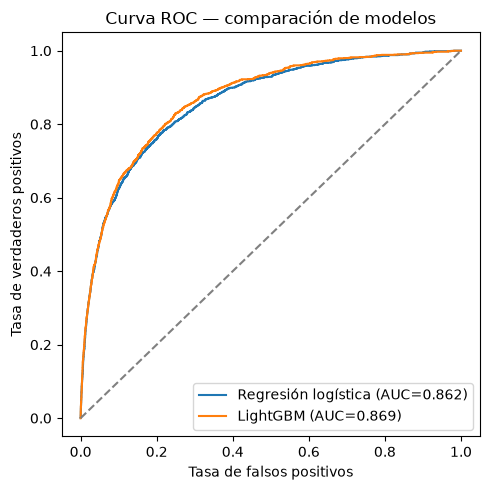

In [7]:
fpr_log, tpr_log, _ = roc_curve(y_test, p_logreg)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_log, tpr_log, label=f'Regresión logística (AUC={auc_logreg:.3f})')
ax.plot(fpr, tpr, label=f'LightGBM (AUC={auc_lgbm:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curva ROC — comparación de modelos')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p3_roc_comparacion.png', dpi=150)
plt.show()

## 4bis. Exportar métricas y curvas (CSV para Power BI)

Curva ROC completa (ambos modelos), métricas resumen, desempeño por tramo de
edad y matriz de confusión — todo en formato largo/tabular, listo para
importar en Power BI sin transformaciones adicionales.

In [8]:
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

roc_combined = pd.concat([
    pd.DataFrame({'modelo': 'Regresión logística', 'fpr': fpr_log, 'tpr': tpr_log}),
    pd.DataFrame({'modelo': 'LightGBM', 'fpr': fpr, 'tpr': tpr}),
], ignore_index=True)
roc_combined.to_csv(POWERBI_DIR / 'modelo_roc.csv', index=False)

modelo_metricas = pd.DataFrame([
    {'modelo': 'Regresión logística', 'auc': auc_logreg, 'ks': ks_logreg},
    {'modelo': 'LightGBM', 'auc': auc_lgbm, 'ks': ks_lgbm},
])
modelo_metricas.to_csv(POWERBI_DIR / 'modelo_metricas.csv', index=False)

edad_perf.reset_index().to_csv(POWERBI_DIR / 'modelo_edad.csv', index=False)

cm = confusion_matrix(y_test, y_pred)
matriz_confusion = pd.DataFrame([
    {'real': 'No impago', 'predicho': 'No impago', 'n': int(cm[0, 0])},
    {'real': 'No impago', 'predicho': 'Impago', 'n': int(cm[0, 1])},
    {'real': 'Impago', 'predicho': 'No impago', 'n': int(cm[1, 0])},
    {'real': 'Impago', 'predicho': 'Impago', 'n': int(cm[1, 1])},
])
matriz_confusion.to_csv(POWERBI_DIR / 'matriz_confusion.csv', index=False)

print('Guardados en', POWERBI_DIR, ': modelo_roc.csv, modelo_metricas.csv, modelo_edad.csv, matriz_confusion.csv')

Guardados en C:\Users\user\Desktop\Analitica\powerbi : modelo_roc.csv, modelo_metricas.csv, modelo_edad.csv, matriz_confusion.csv


## 5. Serialización del modelo ganador

Registrar también en MLflow Model Registry (alias/tags, no stages — ver sección
7.3 del curso).

In [9]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(lgbm, MODELS_DIR / 'scoring_model_v1.joblib')
joblib.dump(bounds, MODELS_DIR / 'preprocessing_bounds_v1.joblib')
print('Modelo y parámetros de limpieza guardados en', MODELS_DIR)

Modelo y parámetros de limpieza guardados en C:\Users\user\Desktop\Analitica\notebooks\models


## 6. Model Card

Los resultados de este notebook (métricas, matriz de confusión,
desagregación por edad y sus implicancias éticas) están documentados en
`docs/model_card.md`.